In [1]:
import optuna
print(optuna.__version__)   # Should show 3.x or higher

# Also double check ax= is supported
import inspect
sig = inspect.signature(optuna.visualization.matplotlib.plot_optimization_history)
print(sig)                  # Should show 'ax' as a parameter

4.8.0
(study: 'Study | Sequence[Study]', *, target: 'Callable[[FrozenTrial], float] | None' = None, target_name: 'str' = 'Objective Value', error_bar: 'bool' = False) -> "'Axes'"


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, KFold
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, brier_score_loss,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.calibration import calibration_curve
import joblib

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120
print('All imports successful')


All imports successful


In [3]:
# ── Paths — update if needed ─────────────────────────────────────────────
df_mat = pd.read_csv('/kaggle/input/datasets/dskagglemt/student-performance-data-set/student-mat.csv', sep=';')
df_por = pd.read_csv('/kaggle/input/datasets/dskagglemt/student-performance-data-set/student-por.csv', sep=';')

# Tag each row with its subject so the model can distinguish them
df_mat['subject'] = 'mat'
df_por['subject'] = 'por'

df = pd.concat([df_mat, df_por], ignore_index=True)

# Ensure grade columns are numeric (they can be quoted strings)
for col in ['G1', 'G2', 'G3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where G3 is missing (a handful in the combined set)
df.dropna(subset=['G3'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Mat rows  : {len(df_mat)}')
print(f'Por rows  : {len(df_por)}')
print(f'Combined  : {df.shape[0]} students x {df.shape[1]} columns')
print(f'Columns   : {list(df.columns)}')
df.head(3)

Mat rows  : 395
Por rows  : 649
Combined  : 1044 students x 34 columns
Columns   : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# 3-A  ORIGINAL COMPOSITE FEATURES
# ══════════════════════════════════════════════════════════════════════════
df['Total_Alcohol']   = df['Dalc'] + df['Walc']
df['Parent_Edu_Sum']  = df['Medu'] + df['Fedu']
df['Social_Life']     = df['goout'] + df['freetime']

# ══════════════════════════════════════════════════════════════════════════
# 3-B  SUPPORT & BEHAVIOUR — binary encoding
# ══════════════════════════════════════════════════════════════════════════
for col in ['schoolsup', 'famsup', 'paid', 'activities', 'internet',
            'higher', 'nursery', 'romantic']:
    df[col + '_bin'] = df[col].map({'yes': 1, 'no': 0})

df['Study_Support'] = df['schoolsup_bin'] + df['famsup_bin'] + df['paid_bin']

# ══════════════════════════════════════════════════════════════════════════
# 3-C  RATIO / EFFICIENCY FEATURES
# ══════════════════════════════════════════════════════════════════════════
df['Study_vs_Social']  = df['studytime'] / (df['Social_Life'] + 1)
df['Study_per_Absent'] = df['studytime'] / (df['absences'] + 1)
df['Support_per_Fail'] = df['Study_Support'] / (df['failures'] + 1)

# ══════════════════════════════════════════════════════════════════════════
# 3-D  COMPOUND RISK FEATURES
# ══════════════════════════════════════════════════════════════════════════
df['Fail_Burden']   = df['failures'] * df['Total_Alcohol']
df['Health_Absence'] = df['health'] * df['absences']
df['Risk_Index']    = (df['failures'] * 2 +
                       df['Total_Alcohol'] +
                       df['absences'] / 10 +
                       (5 - df['health']))

# ══════════════════════════════════════════════════════════════════════════
# 3-E  GRADE TRAJECTORY — CONTINUOUS (G1 & G2 kept as raw scores)
#       No binning or discretisation — XGBoost handles continuous splits
# ══════════════════════════════════════════════════════════════════════════
df['G1_norm']       = df['G1'] / 20.0          # normalise to [0, 1]
df['G2_norm']       = df['G2'] / 20.0
df['G2_G1_delta']   = df['G2'] - df['G1']      # grade change between periods
df['G_avg_P1P2']    = (df['G1'] + df['G2']) / 2.0
df['G1_below_pass'] = (df['G1'] < 10).astype(int)   # soft risk flag (binary, not category)
df['G2_below_pass'] = (df['G2'] < 10).astype(int)
df['Both_failing']  = df['G1_below_pass'] * df['G2_below_pass']

# ══════════════════════════════════════════════════════════════════════════
# 3-F  POLYNOMIAL / INTERACTION
# ══════════════════════════════════════════════════════════════════════════
df['studytime_sq']   = df['studytime'] ** 2
df['absences_log']   = np.log1p(df['absences'])
df['age_failures']   = df['age'] * df['failures']
df['parent_support'] = df['Parent_Edu_Sum'] * df['Study_Support']

print('Feature engineering complete')
print(f'Total columns after engineering: {df.shape[1]}')

Feature engineering complete
Total columns after engineering: 63


In [5]:
# ── Classification target: at-risk if G3 < 10 ────────────────────────────
df['is_at_risk'] = (df['G3'] < 10).astype(int)

# ── Regression target: raw G3 score ──────────────────────────────────────
y_clf  = df['is_at_risk']
y_reg  = df['G3'].astype(float)

# ── Columns to drop from feature matrix ──────────────────────────────────
#    G3 = target (both tasks)
#    is_at_risk = classification target
#    Original columns replaced by composites
#    Binary-converted originals (_bin suffix)
drop_cols = (
    ['G3', 'is_at_risk',
     'Dalc', 'Walc', 'Medu', 'Fedu', 'goout', 'freetime'] +
    [c for c in df.columns if c.endswith('_bin')]
)

X_raw = df.drop(columns=drop_cols)

# ── One-hot encode remaining categoricals ────────────────────────────────
X = pd.get_dummies(X_raw, drop_first=True)

# ── Convert any remaining bool columns to int ────────────────────────────
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

FEATURE_NAMES = X.columns.tolist()

print(f'Feature matrix : {X.shape[0]} students x {X.shape[1]} features')
print(f'Class balance  -> Not-at-risk: {(y_clf==0).sum()}  |  At-risk: {(y_clf==1).sum()}')
print(f'Positive rate  : {y_clf.mean():.1%}')
print(f'G3 score range : {y_reg.min():.0f} – {y_reg.max():.0f}  |  mean={y_reg.mean():.2f}')
print(f'\nSample features: {FEATURE_NAMES[:10]}')

Feature matrix : 1044 students x 57 features
Class balance  -> Not-at-risk: 814  |  At-risk: 230
Positive rate  : 22.0%
G3 score range : 0 – 20  |  mean=11.34

Sample features: ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'health', 'absences', 'G1', 'G2', 'Total_Alcohol']


In [6]:
X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.2, random_state=SEED, stratify=y_clf
)
print(f'Train: {len(y_clf_train)} samples  |  Test: {len(y_clf_test)} samples')

# ── SMOTE: balance training set for classifier ────────────────────────────
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_clf_train_res = sm.fit_resample(X_train, y_clf_train)
print(f'After SMOTE -> {(y_clf_train_res==0).sum()} not-at-risk | {(y_clf_train_res==1).sum()} at-risk')

neg, pos = (y_clf_train == 0).sum(), (y_clf_train == 1).sum()
scale_pos = neg / pos
print(f'scale_pos_weight (pre-SMOTE reference): {scale_pos:.2f}')

Train: 835 samples  |  Test: 209 samples
After SMOTE -> 651 not-at-risk | 651 at-risk
scale_pos_weight (pre-SMOTE reference): 3.54


In [7]:
# ── 6-A  Baseline Classifier ─────────────────────────────────────────────
baseline_clf = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=4,
    eval_metric='logloss', random_state=SEED, verbosity=0
)
baseline_clf.fit(X_train, y_clf_train)
y_pred_base  = baseline_clf.predict(X_test)
y_prob_base  = baseline_clf.predict_proba(X_test)[:, 1]

sep = '-' * 55
print('BASELINE CLASSIFIER')
print(sep)
print(f'  Accuracy : {accuracy_score(y_clf_test, y_pred_base):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_clf_test, y_prob_base):.4f}')
print(f'  F1-Score : {f1_score(y_clf_test, y_pred_base):.4f}')

# ── 6-B  Baseline Regressor ──────────────────────────────────────────────
baseline_reg = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=4,
    eval_metric='rmse', random_state=SEED, verbosity=0
)
baseline_reg.fit(X_train, y_reg_train)
y_pred_reg_base = baseline_reg.predict(X_test)

print('\nBASELINE REGRESSOR (G3 prediction)')
print(sep)
print(f'  MAE  : {mean_absolute_error(y_reg_test, y_pred_reg_base):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_base)):.4f}')
print(f'  R2   : {r2_score(y_reg_test, y_pred_reg_base):.4f}')

BASELINE CLASSIFIER
-------------------------------------------------------
  Accuracy : 0.9043
  ROC-AUC  : 0.9707
  F1-Score : 0.7826

BASELINE REGRESSOR (G3 prediction)
-------------------------------------------------------
  MAE  : 0.7347
  RMSE : 1.0323
  R2   : 0.9308


In [8]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def clf_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma'           : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': 1.0,
        'eval_metric'     : 'auc',
        'random_state'    : SEED,
        'verbosity'       : 0,
        'n_jobs'          : -1,
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(
        model, X_train_res, y_clf_train_res,
        cv=cv_strat, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

clf_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
clf_study.optimize(clf_objective, n_trials=100, show_progress_bar=True)

print(f'\nBest CV ROC-AUC (classifier): {clf_study.best_value:.4f}')
print('Best params:')
for k, v in clf_study.best_params.items():
    print(f'  {k:25s} = {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


Best CV ROC-AUC (classifier): 0.9913
Best params:
  n_estimators              = 139
  max_depth                 = 9
  learning_rate             = 0.15639596219351276
  subsample                 = 0.8597443739602679
  colsample_bytree          = 0.950764935701238
  min_child_weight          = 1
  gamma                     = 0.14117120202324726
  reg_alpha                 = 0.09948422716216732
  reg_lambda                = 0.23779765075732137


In [9]:
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

def reg_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma'           : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'eval_metric'     : 'rmse',
        'random_state'    : SEED,
        'verbosity'       : 0,
        'n_jobs'          : -1,
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_reg_train,
        cv=cv_kfold, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    return scores.mean()   # maximise (neg MAE -> less negative = better)

reg_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
reg_study.optimize(reg_objective, n_trials=100, show_progress_bar=True)

print(f'\nBest CV MAE (regressor): {-reg_study.best_value:.4f}')
print('Best params:')
for k, v in reg_study.best_params.items():
    print(f'  {k:25s} = {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


Best CV MAE (regressor): 0.9020
Best params:
  n_estimators              = 418
  max_depth                 = 4
  learning_rate             = 0.009560236332329098
  subsample                 = 0.8095668467874327
  colsample_bytree          = 0.4031021557509846
  min_child_weight          = 6
  gamma                     = 0.9148225436446565
  reg_alpha                 = 0.05582384177535779
  reg_lambda                = 0.0004055943443346943


In [10]:
# ── 9-A  Best Classifier ─────────────────────────────────────────────────
clf_params = clf_study.best_params.copy()
clf_params.update({
    'n_estimators'    : 1000,
    'eval_metric'     : 'auc',
    'random_state'    : SEED,
    'verbosity'       : 0,
    'n_jobs'          : -1,
    'scale_pos_weight': 1.0,
    'early_stopping_rounds': 30,
})

best_clf = xgb.XGBClassifier(**clf_params)
best_clf.fit(
    X_train_res, y_clf_train_res,
    eval_set=[(X_test, y_clf_test)],
    verbose=False
)
print(f'Classifier best iteration: {best_clf.best_iteration}')

# ── 9-B  Best Regressor ──────────────────────────────────────────────────
reg_params = reg_study.best_params.copy()
reg_params.update({
    'n_estimators'    : 1000,
    'eval_metric'     : 'rmse',
    'random_state'    : SEED,
    'verbosity'       : 0,
    'n_jobs'          : -1,
    'early_stopping_rounds': 30,
})

best_reg = xgb.XGBRegressor(**reg_params)
best_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    verbose=False
)
print(f'Regressor best iteration : {best_reg.best_iteration}')

Classifier best iteration: 32
Regressor best iteration : 353


In [11]:
y_prob = best_clf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_clf_test, y_prob)
f1_arr = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh_idx = np.argmax(f1_arr[:-1])
best_threshold  = float(thresholds[best_thresh_idx])
print(f'F1-optimal threshold: {best_threshold:.3f}')

y_pred_tuned = (y_prob >= best_threshold).astype(int)
y_pred_def   = best_clf.predict(X_test)

F1-optimal threshold: 0.832


In [12]:
def clf_report(name, y_true, y_pred, y_proba):
    sep = '-' * 60
    print(f'\n{sep}')
    print(f'  {name}')
    print(sep)
    print(f'  Accuracy    : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  ROC-AUC     : {roc_auc_score(y_true, y_proba):.4f}')
    print(f'  Avg. Prec.  : {average_precision_score(y_true, y_proba):.4f}')
    print(f'  F1 (at-risk): {f1_score(y_true, y_pred):.4f}')
    print(f'  Brier Score : {brier_score_loss(y_true, y_proba):.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Not-at-risk', 'At-risk']))

clf_report('BASELINE  (no tuning)',              y_clf_test, y_pred_base,  y_prob_base)
clf_report('ENHANCED  (default threshold 0.5)',  y_clf_test, y_pred_def,   y_prob)
clf_report(f'ENHANCED  (tuned threshold {best_threshold:.2f})', y_clf_test, y_pred_tuned, y_prob)

print('\n== G3 REGRESSION RESULTS ==')
y_pred_reg  = best_reg.predict(X_test)
y_pred_reg  = np.clip(y_pred_reg, 0, 20)   # G3 is 0-20
sep = '-' * 60
print(sep)
print(f'  MAE         : {mean_absolute_error(y_reg_test, y_pred_reg):.4f}')
print(f'  RMSE        : {np.sqrt(mean_squared_error(y_reg_test, y_pred_reg)):.4f}')
print(f'  R2          : {r2_score(y_reg_test, y_pred_reg):.4f}')
print(sep)

# ── Cross-Validation on full dataset ─────────────────────────────────────
print('\n-- 5-Fold Cross-Validation (full dataset) --')
n_best_clf = best_clf.best_iteration if best_clf.best_iteration else 200
n_best_reg = best_reg.best_iteration if best_reg.best_iteration else 200

cv_clf = xgb.XGBClassifier(
    **{k: v for k, v in clf_params.items()
       if k not in ['n_estimators', 'early_stopping_rounds','verbosity']},
    n_estimators=n_best_clf, verbosity=0
)
cv_acc = cross_val_score(cv_clf, X, y_clf, cv=cv_strat, scoring='accuracy')
cv_auc = cross_val_score(cv_clf, X, y_clf, cv=cv_strat, scoring='roc_auc')
print(f'  Classifier Accuracy : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'  Classifier ROC-AUC  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

cv_reg = xgb.XGBRegressor(
    **{k: v for k, v in reg_params.items()
       if k not in ['n_estimators', 'early_stopping_rounds','verbosity']},
    n_estimators=n_best_reg, verbosity=0
)
cv_mae = cross_val_score(cv_reg, X, y_reg, cv=cv_kfold, scoring='neg_mean_absolute_error')
cv_r2  = cross_val_score(cv_reg, X, y_reg, cv=cv_kfold, scoring='r2')
print(f'  Regressor MAE       : {-cv_mae.mean():.4f} +/- {cv_mae.std():.4f}')
print(f'  Regressor R2        : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')


------------------------------------------------------------
  BASELINE  (no tuning)
------------------------------------------------------------
  Accuracy    : 0.9043
  ROC-AUC     : 0.9707
  Avg. Prec.  : 0.9204
  F1 (at-risk): 0.7826
  Brier Score : 0.0594

              precision    recall  f1-score   support

 Not-at-risk       0.94      0.94      0.94       163
     At-risk       0.78      0.78      0.78        46

    accuracy                           0.90       209
   macro avg       0.86      0.86      0.86       209
weighted avg       0.90      0.90      0.90       209


------------------------------------------------------------
  ENHANCED  (default threshold 0.5)
------------------------------------------------------------
  Accuracy    : 0.9139
  ROC-AUC     : 0.9752
  Avg. Prec.  : 0.9288
  F1 (at-risk): 0.8163
  Brier Score : 0.0626

              precision    recall  f1-score   support

 Not-at-risk       0.96      0.93      0.94       163
     At-risk       0.77   

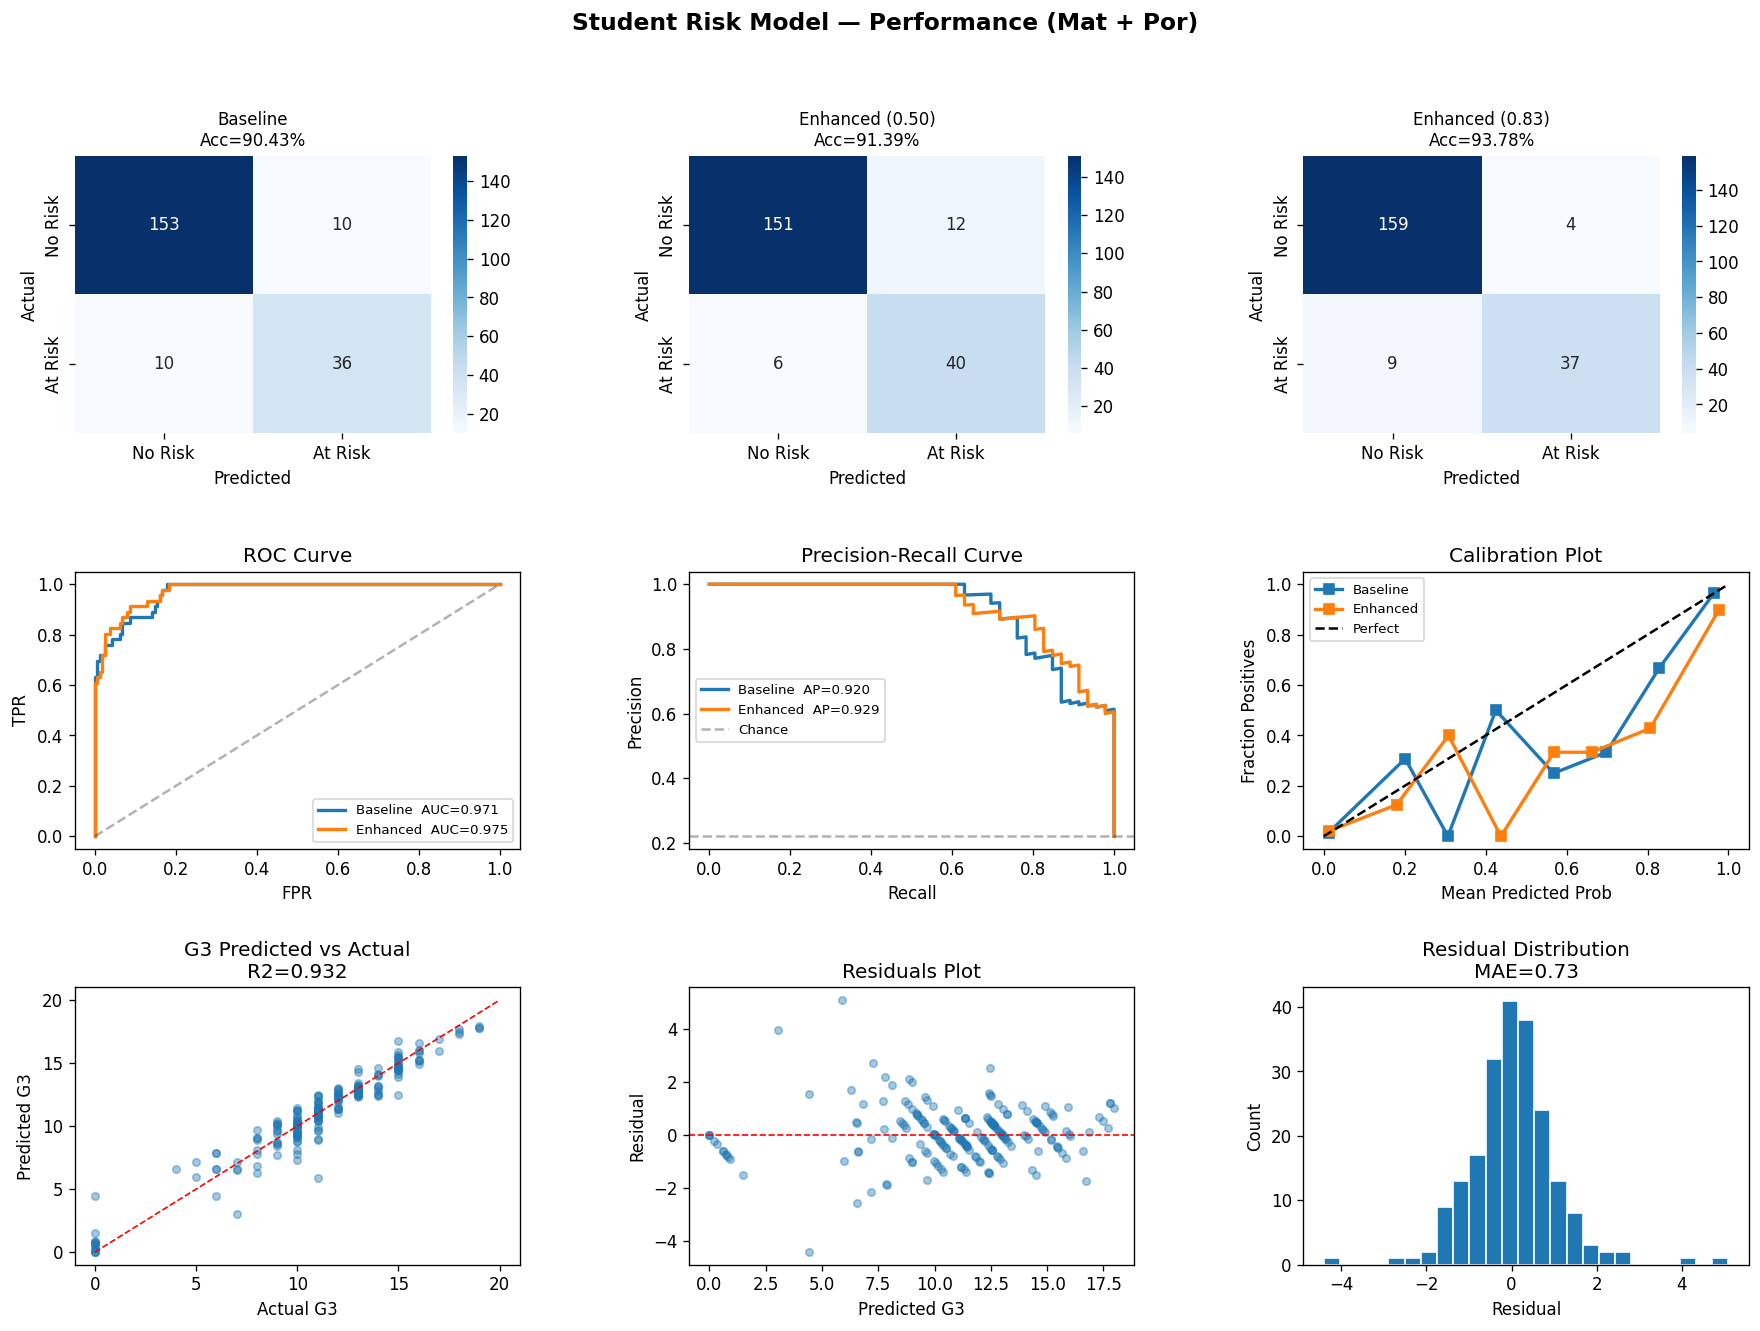

Saved: model_performance.png


In [13]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── Row 0: Confusion matrices ─────────────────────────────────────────────
for i, (preds, title) in enumerate([
    (y_pred_base,  f'Baseline\nAcc={accuracy_score(y_clf_test, y_pred_base):.2%}'),
    (y_pred_def,   f'Enhanced (0.50)\nAcc={accuracy_score(y_clf_test, y_pred_def):.2%}'),
    (y_pred_tuned, f'Enhanced ({best_threshold:.2f})\nAcc={accuracy_score(y_clf_test, y_pred_tuned):.2%}'),
]):
    ax = fig.add_subplot(gs[0, i])
    cm = confusion_matrix(y_clf_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Risk', 'At Risk'],
                yticklabels=['No Risk', 'At Risk'])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ── Row 1: ROC / PR / Calibration ────────────────────────────────────────
ax_roc = fig.add_subplot(gs[1, 0])
for probs, label in [
    (y_prob_base, f'Baseline  AUC={roc_auc_score(y_clf_test, y_prob_base):.3f}'),
    (y_prob,      f'Enhanced  AUC={roc_auc_score(y_clf_test, y_prob):.3f}'),
]:
    fpr, tpr, _ = roc_curve(y_clf_test, probs)
    ax_roc.plot(fpr, tpr, linewidth=2, label=label)
ax_roc.plot([0,1],[0,1],'k--', alpha=0.3)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curve'); ax_roc.legend(fontsize=8)

ax_pr = fig.add_subplot(gs[1, 1])
for probs, label in [
    (y_prob_base, f'Baseline  AP={average_precision_score(y_clf_test, y_prob_base):.3f}'),
    (y_prob,      f'Enhanced  AP={average_precision_score(y_clf_test, y_prob):.3f}'),
]:
    p, r, _ = precision_recall_curve(y_clf_test, probs)
    ax_pr.plot(r, p, linewidth=2, label=label)
ax_pr.axhline(y=y_clf.mean(), color='k', linestyle='--', alpha=0.3, label='Chance')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve'); ax_pr.legend(fontsize=8)

ax_cal = fig.add_subplot(gs[1, 2])
for probs, label in [(y_prob_base, 'Baseline'), (y_prob, 'Enhanced')]:
    frac_pos, mean_pred = calibration_curve(y_clf_test, probs, n_bins=8)
    ax_cal.plot(mean_pred, frac_pos, 's-', linewidth=2, label=label)
ax_cal.plot([0,1],[0,1],'k--', label='Perfect')
ax_cal.set_xlabel('Mean Predicted Prob'); ax_cal.set_ylabel('Fraction Positives')
ax_cal.set_title('Calibration Plot'); ax_cal.legend(fontsize=8)

# ── Row 2: G3 Regression diagnostics ─────────────────────────────────────
ax_scatter = fig.add_subplot(gs[2, 0])
ax_scatter.scatter(y_reg_test, y_pred_reg, alpha=0.4, s=20)
lims = [0, 20]
ax_scatter.plot(lims, lims, 'r--', linewidth=1)
ax_scatter.set_xlabel('Actual G3'); ax_scatter.set_ylabel('Predicted G3')
ax_scatter.set_title(f'G3 Predicted vs Actual\nR2={r2_score(y_reg_test, y_pred_reg):.3f}')

ax_resid = fig.add_subplot(gs[2, 1])
residuals = y_reg_test.values - y_pred_reg
ax_resid.scatter(y_pred_reg, residuals, alpha=0.4, s=20)
ax_resid.axhline(0, color='r', linestyle='--', linewidth=1)
ax_resid.set_xlabel('Predicted G3'); ax_resid.set_ylabel('Residual')
ax_resid.set_title('Residuals Plot')

ax_hist = fig.add_subplot(gs[2, 2])
ax_hist.hist(residuals, bins=25, edgecolor='white')
ax_hist.set_xlabel('Residual'); ax_hist.set_ylabel('Count')
ax_hist.set_title(f'Residual Distribution\nMAE={mean_absolute_error(y_reg_test, y_pred_reg):.2f}')

plt.suptitle('Student Risk Model — Performance (Mat + Por)', fontsize=14, fontweight='bold')
plt.savefig('model_performance.png', bbox_inches='tight')
plt.show()
print('Saved: model_performance.png')

In [14]:
explainer_clf  = shap.TreeExplainer(best_clf)
shap_vals_clf  = explainer_clf.shap_values(X_test)
shap_exp_clf   = explainer_clf(X_test)
print(f'SHAP values shape (classifier): {shap_vals_clf.shape}')

SHAP values shape (classifier): (209, 57)


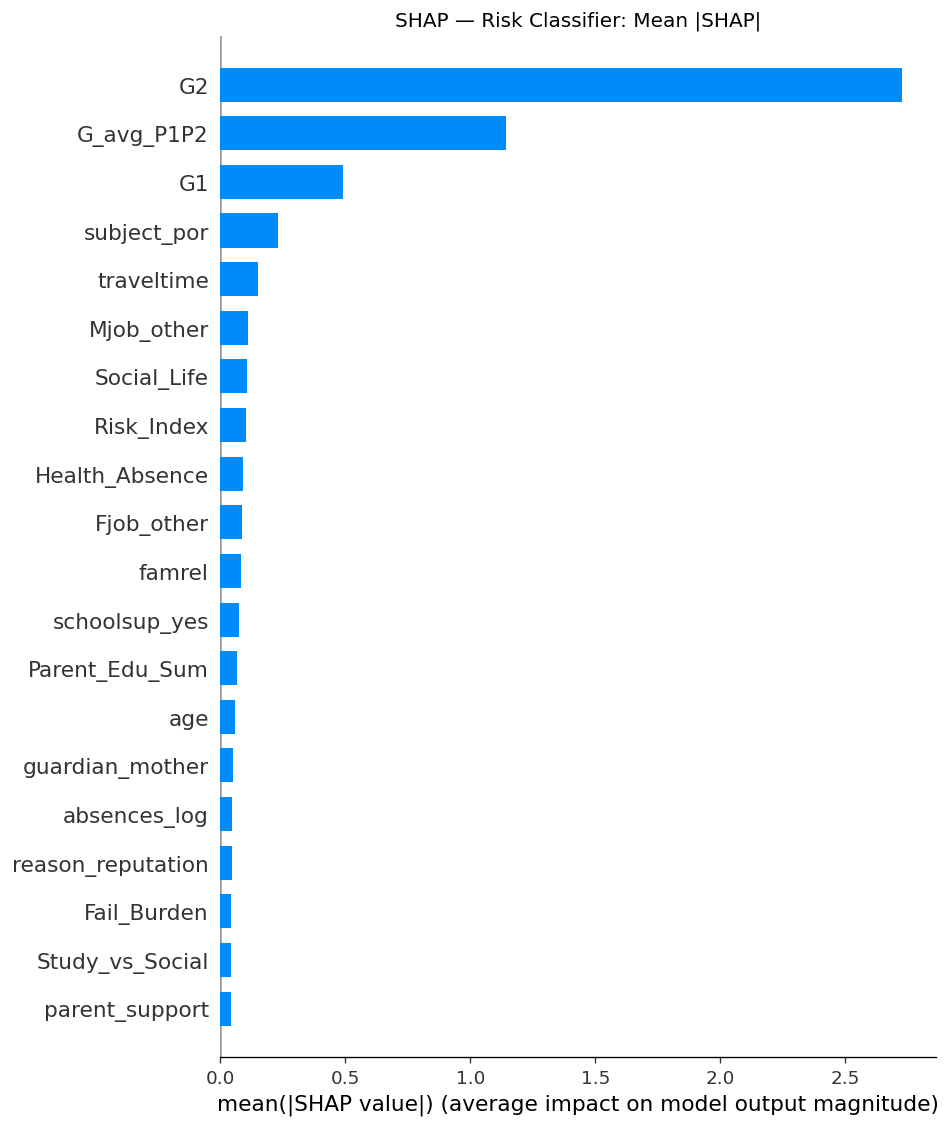

In [15]:
# ── 13-A  Summary Bar ─────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals_clf, X_test, plot_type='bar',
                  show=False, max_display=20)
plt.title('SHAP — Risk Classifier: Mean |SHAP|', fontsize=12)
plt.tight_layout()
plt.savefig('shap_clf_bar.png', bbox_inches='tight')
plt.show()

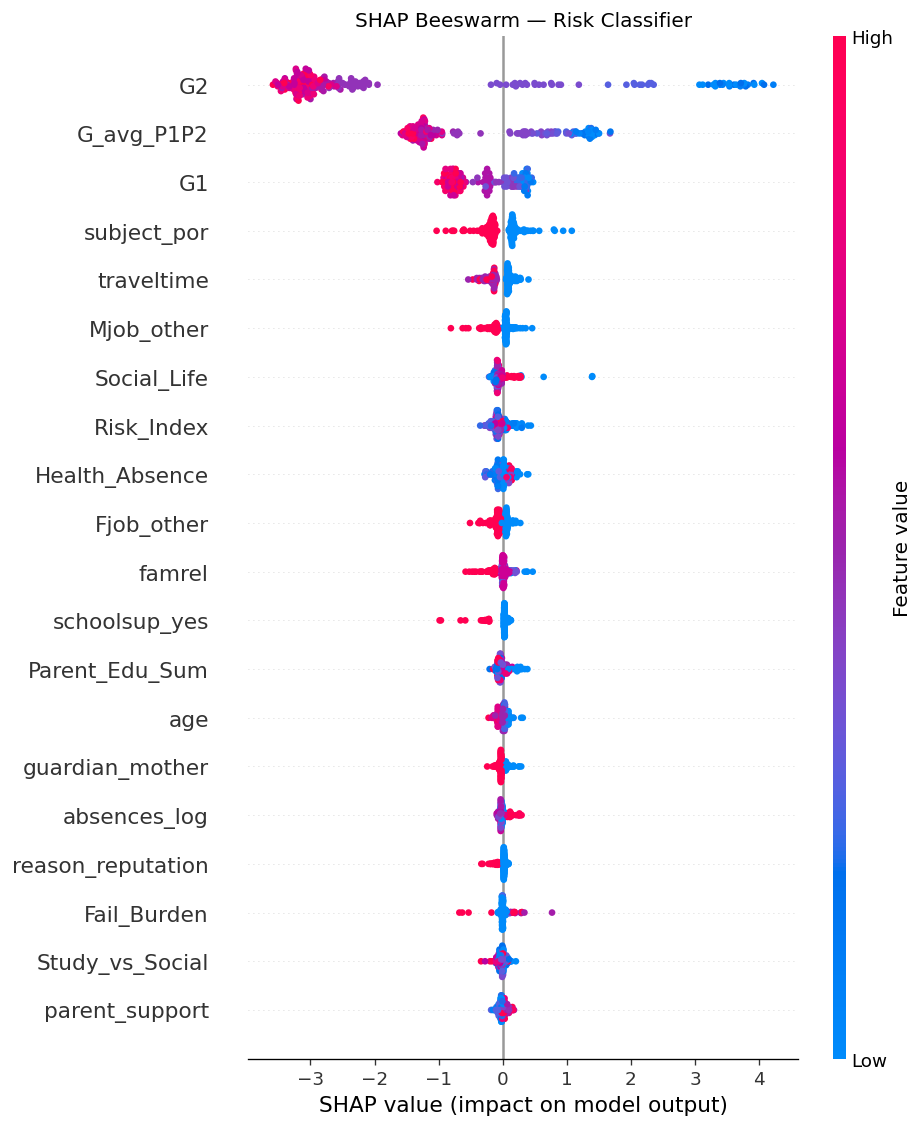

In [16]:
# ── 13-B  Beeswarm ────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals_clf, X_test, plot_type='dot',
                  show=False, max_display=20)
plt.title('SHAP Beeswarm — Risk Classifier', fontsize=12)
plt.tight_layout()
plt.savefig('shap_clf_beeswarm.png', bbox_inches='tight')
plt.show()

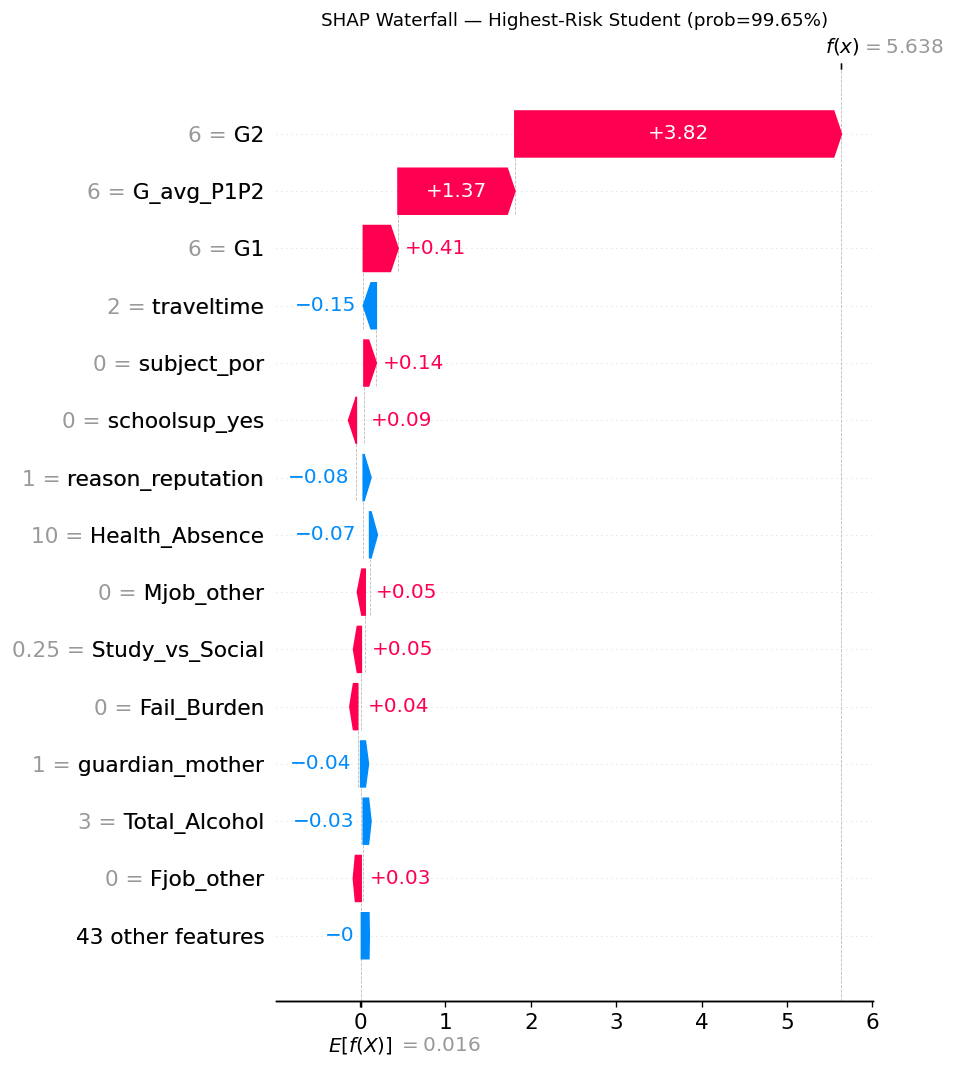

In [17]:
# ── 13-C  Waterfall — highest-risk student ────────────────────────────────
at_risk_idx  = np.where(y_clf_test.values == 1)[0]
highest_risk = at_risk_idx[np.argmax(y_prob[at_risk_idx])]

plt.figure(figsize=(9, 6))
shap.waterfall_plot(shap_exp_clf[highest_risk], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Highest-Risk Student (prob={y_prob[highest_risk]:.2%})',
          fontsize=11)
plt.tight_layout()
plt.savefig('shap_clf_waterfall.png', bbox_inches='tight')
plt.show()

In [18]:
# ── 13-D  Force Plot (interactive in Jupyter) ─────────────────────────────
shap.initjs()
force_plot = shap.force_plot(
    explainer_clf.expected_value,
    shap_vals_clf[highest_risk],
    X_test.iloc[highest_risk],
    feature_names=FEATURE_NAMES
)
display(force_plot)

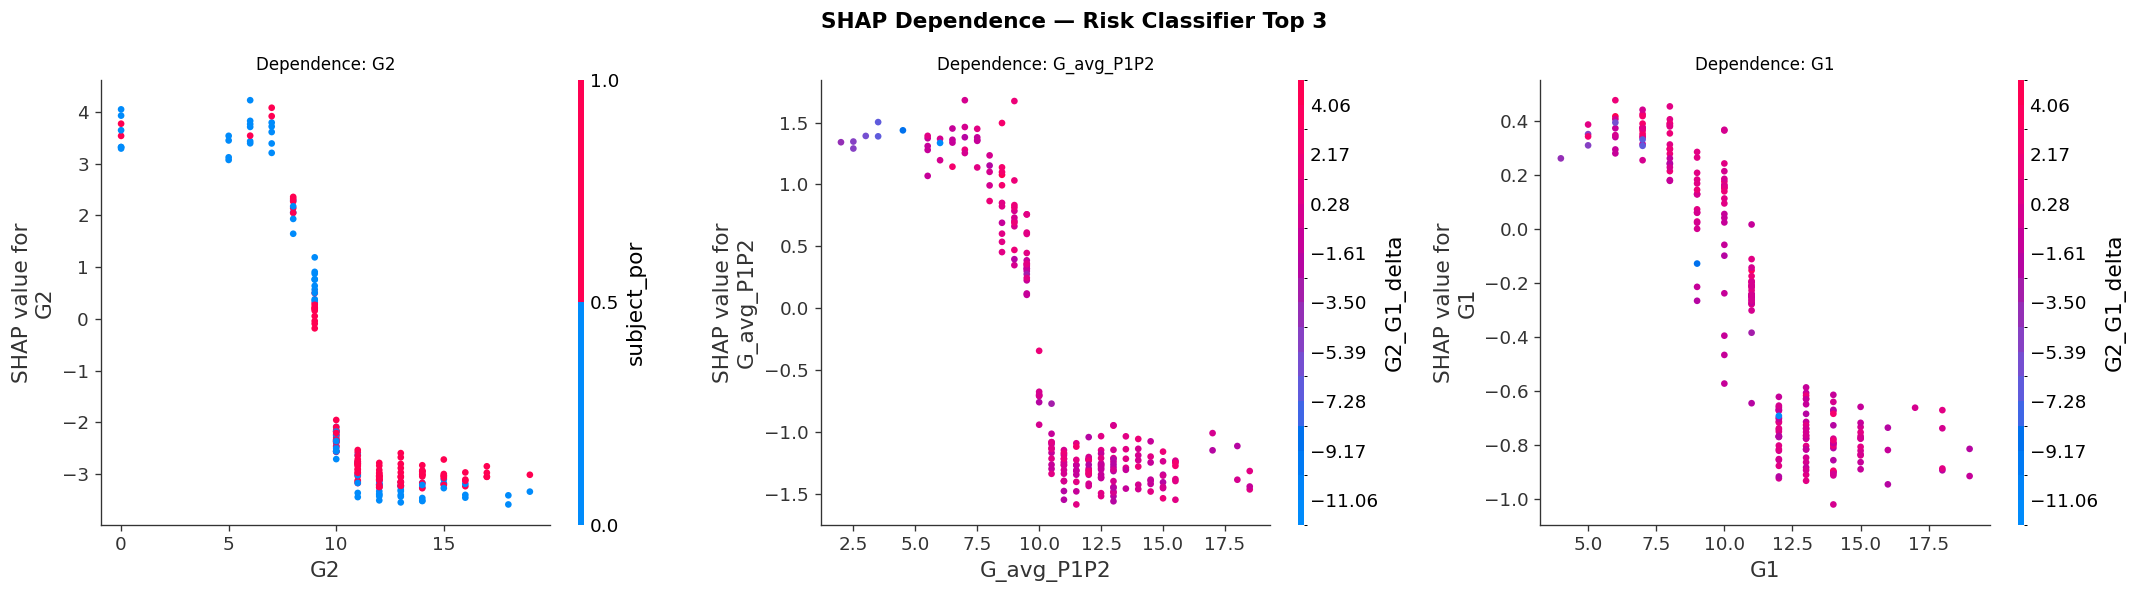

In [19]:
# ── 13-E  Dependence Plots — Top 3 features ───────────────────────────────
mean_abs_shap_clf = np.abs(shap_vals_clf).mean(axis=0)
top3_clf = [FEATURE_NAMES[i] for i in np.argsort(mean_abs_shap_clf)[::-1][:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_clf):
    feat_idx = FEATURE_NAMES.index(feat)
    shap.dependence_plot(
        feat_idx, shap_vals_clf, X_test,
        feature_names=FEATURE_NAMES, ax=ax, show=False
    )
    ax.set_title(f'Dependence: {feat}', fontsize=10)

plt.suptitle('SHAP Dependence — Risk Classifier Top 3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_clf_dependence.png', bbox_inches='tight')
plt.show()

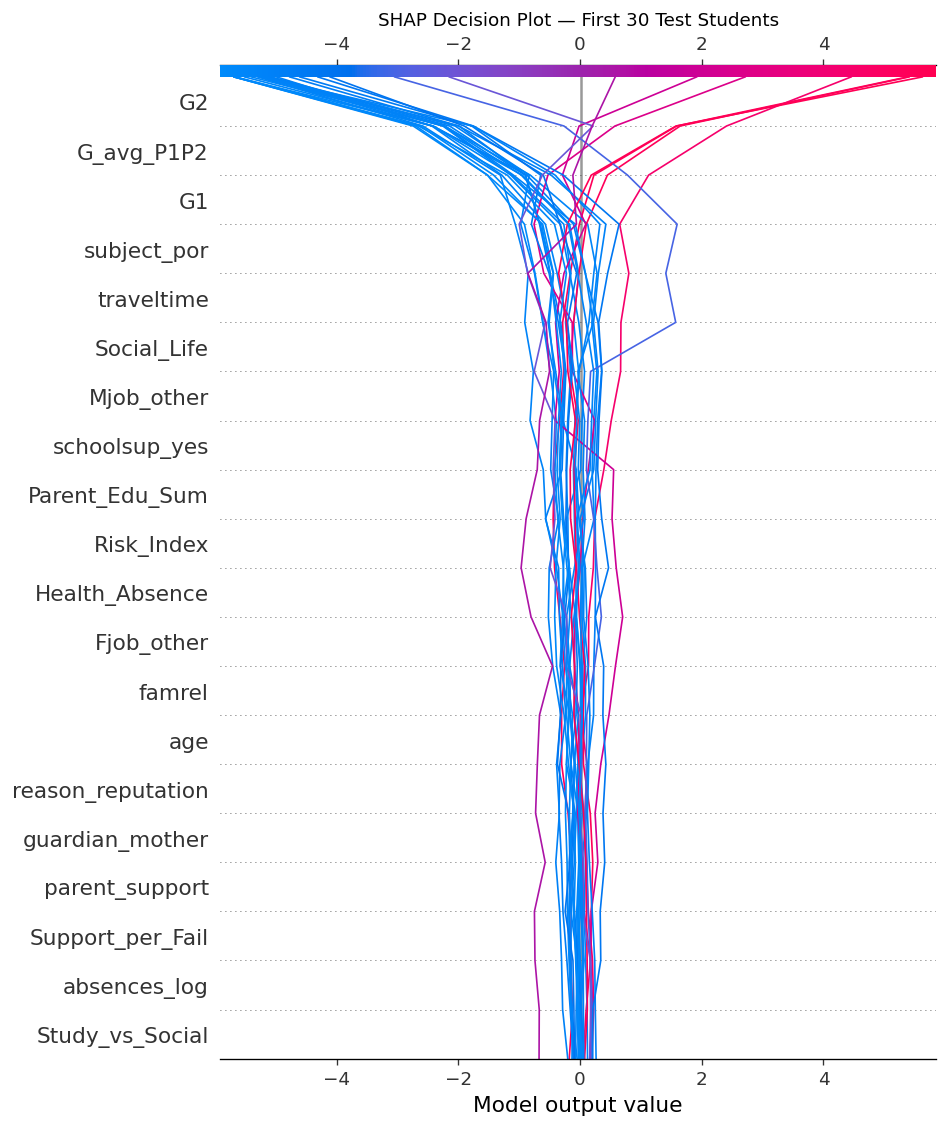

In [20]:
# ── 13-F  Decision Plot — first 30 test students ──────────────────────────
plt.figure(figsize=(9, 7))
shap.decision_plot(
    explainer_clf.expected_value,
    shap_vals_clf[:30],
    feature_names=FEATURE_NAMES,
    show=False
)
plt.title('SHAP Decision Plot — First 30 Test Students', fontsize=11)
plt.tight_layout()
plt.savefig('shap_clf_decision.png', bbox_inches='tight')
plt.show()

SHAP values shape (regressor): (209, 57)


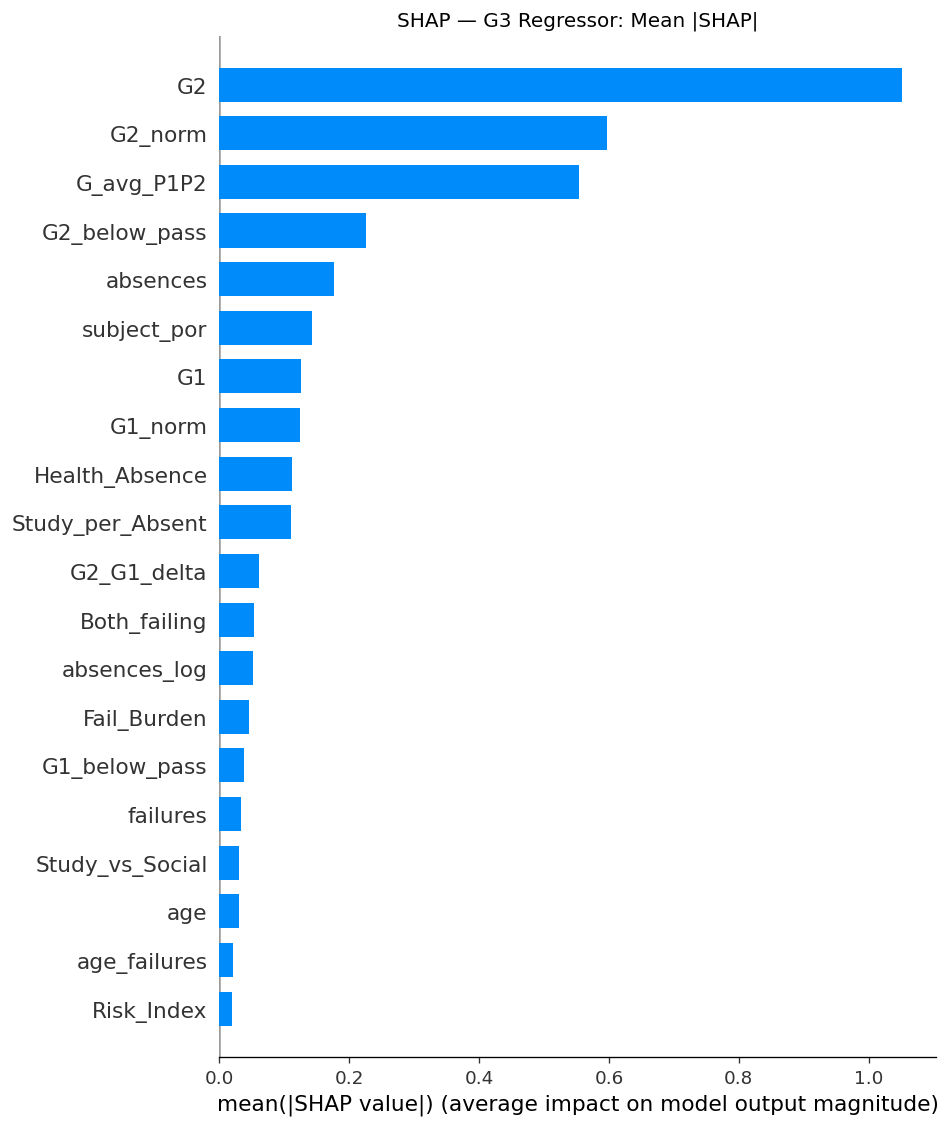

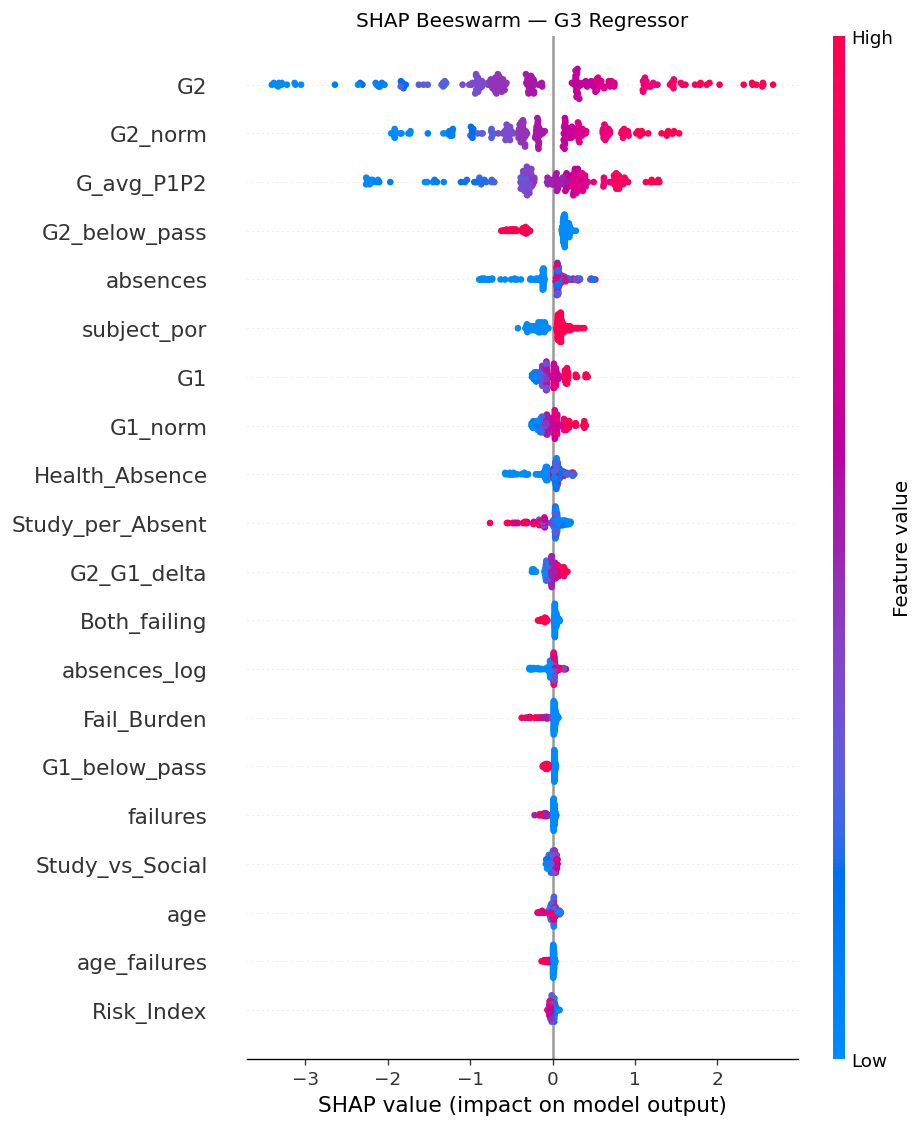

In [21]:
explainer_reg  = shap.TreeExplainer(best_reg)
shap_vals_reg  = explainer_reg.shap_values(X_test)
shap_exp_reg   = explainer_reg(X_test)
print(f'SHAP values shape (regressor): {shap_vals_reg.shape}')

# ── Summary Bar ───────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals_reg, X_test, plot_type='bar',
                  show=False, max_display=20)
plt.title('SHAP — G3 Regressor: Mean |SHAP|', fontsize=12)
plt.tight_layout()
plt.savefig('shap_reg_bar.png', bbox_inches='tight')
plt.show()

# ── Beeswarm ──────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals_reg, X_test, plot_type='dot',
                  show=False, max_display=20)
plt.title('SHAP Beeswarm — G3 Regressor', fontsize=12)
plt.tight_layout()
plt.savefig('shap_reg_beeswarm.png', bbox_inches='tight')
plt.show()

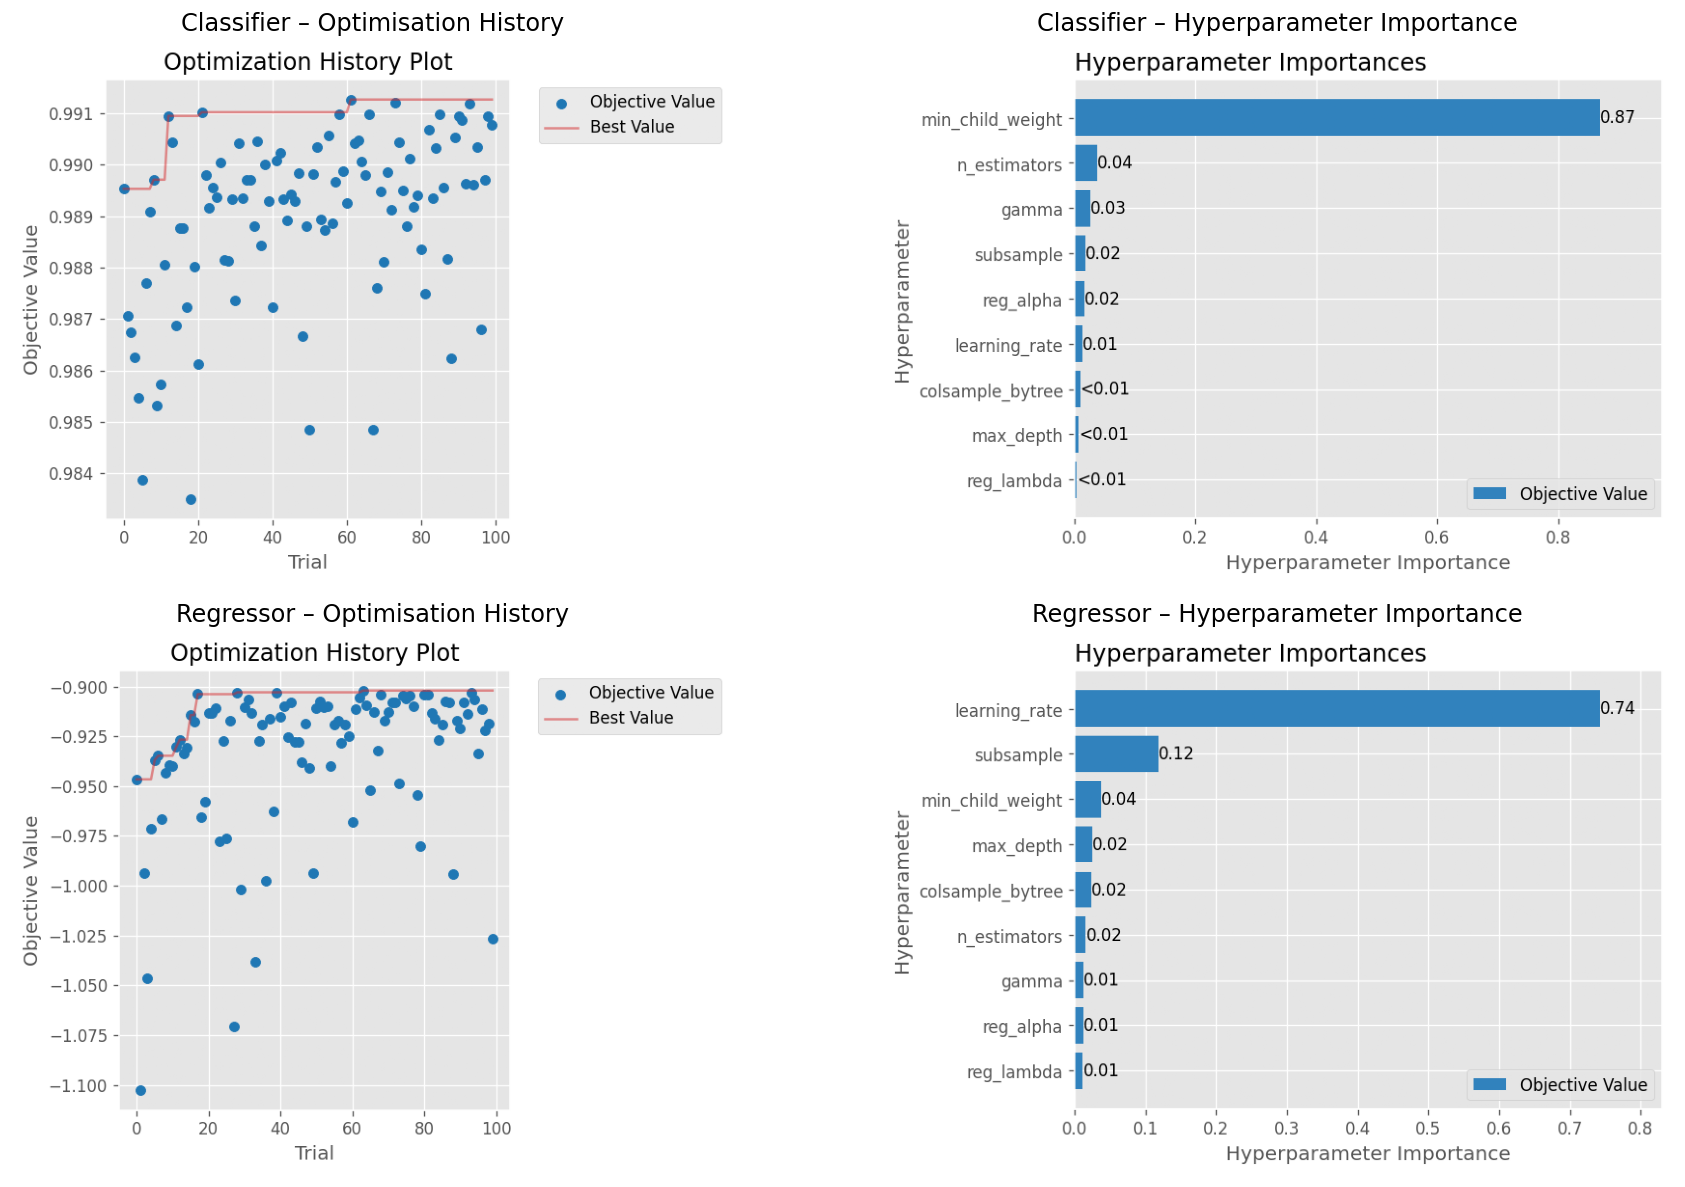

In [22]:
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

configs = [
    (plot_optimization_history, clf_study, 'Classifier – Optimisation History',     axes[0, 0]),
    (plot_param_importances,    clf_study, 'Classifier – Hyperparameter Importance', axes[0, 1]),
    (plot_optimization_history, reg_study, 'Regressor – Optimisation History',      axes[1, 0]),
    (plot_param_importances,    reg_study, 'Regressor – Hyperparameter Importance',  axes[1, 1]),
]

for func, study, title, ax in configs:
    returned_ax = func(study)          # Optuna draws into its own figure
    tmp_fig = returned_ax.get_figure() # grab that figure
    buf = io.BytesIO()
    tmp_fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = mpimg.imread(buf)
    ax.imshow(img)                     # paste into your subplot
    ax.set_title(title)
    ax.axis('off')
    plt.close(tmp_fig)                 # clean up

plt.tight_layout()
plt.savefig('optuna_history.png', bbox_inches='tight')
plt.show()

In [23]:
results = {
    'Model'    : ['Baseline Clf', 'Enhanced (0.50)', f'Enhanced ({best_threshold:.2f})'],
    'Accuracy' : [accuracy_score(y_clf_test, y_pred_base),
                  accuracy_score(y_clf_test, y_pred_def),
                  accuracy_score(y_clf_test, y_pred_tuned)],
    'ROC-AUC'  : [roc_auc_score(y_clf_test, y_prob_base),
                  roc_auc_score(y_clf_test, y_prob),
                  roc_auc_score(y_clf_test, y_prob)],
    'F1 (risk)': [f1_score(y_clf_test, y_pred_base),
                  f1_score(y_clf_test, y_pred_def),
                  f1_score(y_clf_test, y_pred_tuned)],
    'Avg. Prec': [average_precision_score(y_clf_test, y_prob_base),
                  average_precision_score(y_clf_test, y_prob),
                  average_precision_score(y_clf_test, y_prob)],
}
res_df = pd.DataFrame(results).set_index('Model')
display(res_df.style.format('{:.4f}').background_gradient(cmap='Greens'))

print('\nG3 REGRESSION SUMMARY')
print(f'  MAE  : {mean_absolute_error(y_reg_test, y_pred_reg):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_reg_test, y_pred_reg)):.4f}')
print(f'  R2   : {r2_score(y_reg_test, y_pred_reg):.4f}')

print('\nTop 10 SHAP Features (classifier, mean |SHAP|):')
shap_imp_clf = pd.Series(mean_abs_shap_clf, index=FEATURE_NAMES)
shap_imp_clf = shap_imp_clf.sort_values(ascending=False).head(10)
print(shap_imp_clf.to_string())

,Accuracy,ROC-AUC,F1 (risk),Avg. Prec
Model,,,,
Baseline Clf,0.9043,0.9707,0.7826,0.9204
Enhanced (0.50),0.9139,0.9752,0.8163,0.9288
Enhanced (0.83),0.9378,0.9752,0.8506,0.9288



G3 REGRESSION SUMMARY
  MAE  : 0.7306
  RMSE : 1.0195
  R2   : 0.9325

Top 10 SHAP Features (classifier, mean |SHAP|):
G2                2.725846
G_avg_P1P2        1.142748
G1                0.489355
subject_por       0.228849
traveltime        0.152101
Mjob_other        0.109830
Social_Life       0.106674
Risk_Index        0.100713
Health_Absence    0.088480
Fjob_other        0.088031


In [24]:
joblib.dump(best_clf,      'xgb_risk_classifier.pkl')
joblib.dump(best_reg,      'xgb_g3_regressor.pkl')
joblib.dump(FEATURE_NAMES, 'feature_names.pkl')
joblib.dump(best_threshold,'best_threshold.pkl')

print('Models saved:')
print('  xgb_risk_classifier.pkl')
print('  xgb_g3_regressor.pkl')
print('  feature_names.pkl')
print('  best_threshold.pkl')

Models saved:
  xgb_risk_classifier.pkl
  xgb_g3_regressor.pkl
  feature_names.pkl
  best_threshold.pkl


In [25]:
def engineer_features(df_new: pd.DataFrame) -> pd.DataFrame:
    """Apply the same feature engineering used during training."""
    df_e = df_new.copy()

    # Ensure grade columns are numeric
    for col in ['G1', 'G2']:
        df_e[col] = pd.to_numeric(df_e[col], errors='coerce').fillna(0)

    # Composites
    df_e['Total_Alcohol']   = df_e['Dalc'] + df_e['Walc']
    df_e['Parent_Edu_Sum']  = df_e['Medu'] + df_e['Fedu']
    df_e['Social_Life']     = df_e['goout'] + df_e['freetime']

    # Binary encodings
    for col in ['schoolsup', 'famsup', 'paid', 'activities', 'internet',
                'higher', 'nursery', 'romantic']:
        if col in df_e.columns:
            df_e[col + '_bin'] = df_e[col].map({'yes': 1, 'no': 0}).fillna(0)
    df_e['Study_Support'] = df_e.get('schoolsup_bin', 0) + df_e.get('famsup_bin', 0) + df_e.get('paid_bin', 0)

    # Ratios
    df_e['Study_vs_Social']  = df_e['studytime'] / (df_e['Social_Life'] + 1)
    df_e['Study_per_Absent'] = df_e['studytime'] / (df_e['absences'] + 1)
    df_e['Support_per_Fail'] = df_e['Study_Support'] / (df_e['failures'] + 1)

    # Risk compounds
    df_e['Fail_Burden']    = df_e['failures'] * df_e['Total_Alcohol']
    df_e['Health_Absence'] = df_e['health'] * df_e['absences']
    df_e['Risk_Index']     = (df_e['failures'] * 2 +
                               df_e['Total_Alcohol'] +
                               df_e['absences'] / 10 +
                               (5 - df_e['health']))

    # Grade trajectory — continuous
    df_e['G1_norm']       = df_e['G1'] / 20.0
    df_e['G2_norm']       = df_e['G2'] / 20.0
    df_e['G2_G1_delta']   = df_e['G2'] - df_e['G1']
    df_e['G_avg_P1P2']    = (df_e['G1'] + df_e['G2']) / 2.0
    df_e['G1_below_pass'] = (df_e['G1'] < 10).astype(int)
    df_e['G2_below_pass'] = (df_e['G2'] < 10).astype(int)
    df_e['Both_failing']  = df_e['G1_below_pass'] * df_e['G2_below_pass']

    # Polynomial
    df_e['studytime_sq']  = df_e['studytime'] ** 2
    df_e['absences_log']  = np.log1p(df_e['absences'])
    df_e['age_failures']  = df_e['age'] * df_e['failures']
    df_e['parent_support'] = df_e['Parent_Edu_Sum'] * df_e['Study_Support']

    return df_e


def predict_student(new_data: pd.DataFrame,
                    clf=best_clf, reg=best_reg,
                    feat_names=FEATURE_NAMES,
                    threshold=best_threshold) -> pd.DataFrame:
    """
    Score new students.

    Parameters
    ----------
    new_data : DataFrame with the same raw columns as the original CSVs
               (minus G3 — that's what we predict).

    Returns
    -------
    DataFrame with columns:
        risk_probability  – P(G3 < 10)
        is_at_risk        – binary flag using the F1-optimal threshold
        predicted_G3      – continuous G3 score (0-20)
    """
    df_e = engineer_features(new_data)

    # Drop original columns replaced by composites / binaries
    drop_cols = (
        ['G3', 'is_at_risk',
         'Dalc', 'Walc', 'Medu', 'Fedu', 'goout', 'freetime'] +
        [c for c in df_e.columns if c.endswith('_bin')]
    )
    df_e = df_e.drop(columns=[c for c in drop_cols if c in df_e.columns])

    # One-hot encode & align to training feature set
    X_new = pd.get_dummies(df_e, drop_first=True)
    bool_c = X_new.select_dtypes(include='bool').columns
    X_new[bool_c] = X_new[bool_c].astype(int)
    X_new = X_new.reindex(columns=feat_names, fill_value=0)

    risk_prob = clf.predict_proba(X_new)[:, 1]
    is_at_risk = (risk_prob >= threshold).astype(int)
    g3_pred    = np.clip(reg.predict(X_new), 0, 20)

    return pd.DataFrame({
        'risk_probability': risk_prob.round(4),
        'is_at_risk'      : is_at_risk,
        'predicted_G3'    : g3_pred.round(2),
    })


# ── Demo: predict on the held-out test set ───────────────────────────────
# Reconstruct a raw-format test slice for demonstration
raw_test_cols = df_mat.drop(columns=['G3']).columns.tolist()
test_indices  = X_test.index

# Use the original combined df (before feature engineering) as "new data"
new_demo = df.loc[test_indices, [c for c in df.columns
                                  if c not in ['G3', 'is_at_risk']]].copy()

preds_demo = predict_student(new_demo)
print('Sample predictions on test set:')
display(preds_demo.head(10))

# Quick accuracy check vs true labels
demo_acc = accuracy_score(y_clf_test, preds_demo['is_at_risk'])
demo_auc = roc_auc_score(y_clf_test, preds_demo['risk_probability'])
demo_mae = mean_absolute_error(y_reg_test, preds_demo['predicted_G3'])
print(f'\nVerification on test set:')
print(f'  Risk classifier accuracy : {demo_acc:.4f}')
print(f'  Risk classifier ROC-AUC  : {demo_auc:.4f}')
print(f'  G3 regressor MAE         : {demo_mae:.4f}')

Sample predictions on test set:


,risk_probability,is_at_risk,predicted_G3
0,0.9954,1,7.71
1,0.0084,0,12.31
2,0.0053,0,17.48
3,0.0060,0,11.34
4,0.0034,0,14.38
5,0.9885,1,6.50
6,0.0050,0,11.41
7,0.0062,0,12.38
8,0.0034,0,12.64
9,0.0068,0,10.84



Verification on test set:
  Risk classifier accuracy : 0.9378
  Risk classifier ROC-AUC  : 0.9752
  G3 regressor MAE         : 0.7310
